In [1]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import describe
import missingno as msno

FUNCIONES AUXILIARES

In [2]:
# FUNCIONES AUXILIARES
def plot_histograma(data, column, figsize=(6, 3), bins=15, kde=True, mvd=True, shade=True, snk=False):
    skewness = (data[column]).skew()
    kurtosis = (data[column]).kurt()
    media = (data[column]).mean()
    var = (data[column]).var()
    std = (data[column]).std()
    
    plt.figure(figsize=figsize)
    plt.grid(axis='y')
    sns.histplot(data[column], bins=bins, kde=kde)
    
    if snk:
        plt.figtext(0.7, 0.8, f'Asimetría: {skewness:.2f}', fontsize=10, color='blue')
        plt.figtext(0.715, 0.73, f'Curtosis: {kurtosis:.2f}', fontsize=10, color='blue')
        plt.axvline(media, color='red', linestyle='--', label='Media')

    if mvd and shade:
        plt.axvspan(media - std, media + std, alpha=0.1, color='orange', label='±1 Std')
        plt.axvline(media + std, color='orange', linestyle=':', label='+1 Std')
        plt.axvline(media - std, color='orange', linestyle=':', label='-1 Std')
        plt.figtext(0.15, 0.80, f'Media: {media:.2f}', fontsize=10, color='red')
        plt.figtext(0.15, 0.73, f'Var:   {var:.2f}',   fontsize=10, color='red')
        plt.figtext(0.15, 0.66, f'Std:   {std:.2f}',   fontsize=10, color='orange')

    plt.title(f'Variable: {column}')
    plt.xlabel(f'{column}')
    plt.ylabel('Frecuencia')
    plt.show()

2. CARGA Y LIMPIEZA DE DATOS


Se procede a hacer la carga y limpieza de los datos. Como primera medida se hace la carga inicial de datos
y se procede a realizar un analisis de los datos nulos.

In [13]:
# Carga inicial y diagnóstico general
df_csv = pd.read_csv("datasets/player_stats.csv")
print("Cantidad de filas y columnas =", df_csv.shape)

df_csv.info()

Cantidad de filas y columnas = (1248, 21)
<class 'pandas.DataFrame'>
RangeIndex: 1248 entries, 0 to 1247
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   player_id        1248 non-null   int64  
 1   player_name      1248 non-null   str    
 2   team_id          1248 non-null   int64  
 3   position         1248 non-null   str    
 4   matches_played   1248 non-null   int64  
 5   matches_started  1248 non-null   int64  
 6   minutes_played   1248 non-null   int64  
 7   goals            1248 non-null   int64  
 8   assists          1248 non-null   int64  
 9   shots            0 non-null      float64
 10  shots_on_target  0 non-null      float64
 11  yellow_cards     1248 non-null   int64  
 12  red_cards        1248 non-null   int64  
 13  penalty_goals    1248 non-null   int64  
 14  own_goals        1248 non-null   int64  
 15  clean_sheets     145 non-null    float64
 16  saves            145 non-null

Visualización de datos nulos

 Diagnostico Visual --> msno.matrix
    Genera un mapa donde las lineas blancas representan valrores nulos y las areas oscuras los datos presentes.

- Funcion nulos_por_grupo
    Agrupa la tabla segun una variable categorica (position) y calcula que porcentaje exacto de valores faltan 
    en una metrica especifica como (saves).

HIPOTESIS MAR --> la función es utilizada a proposito , me demuestra que los datos nulos estan condicionados por 
la posicion. MAR = Missing at Random

--Tabla de nulos--
                 cantidad de nulos  Porcentaje
shots                         1248  100.000000
shots_on_target               1248  100.000000
clean_sheets                  1103   88.381410
saves                         1103   88.381410
goals_conceded                1103   88.381410
average_rating                1248  100.000000
data_source                    209   16.746795


<Figure size 1000x400 with 0 Axes>

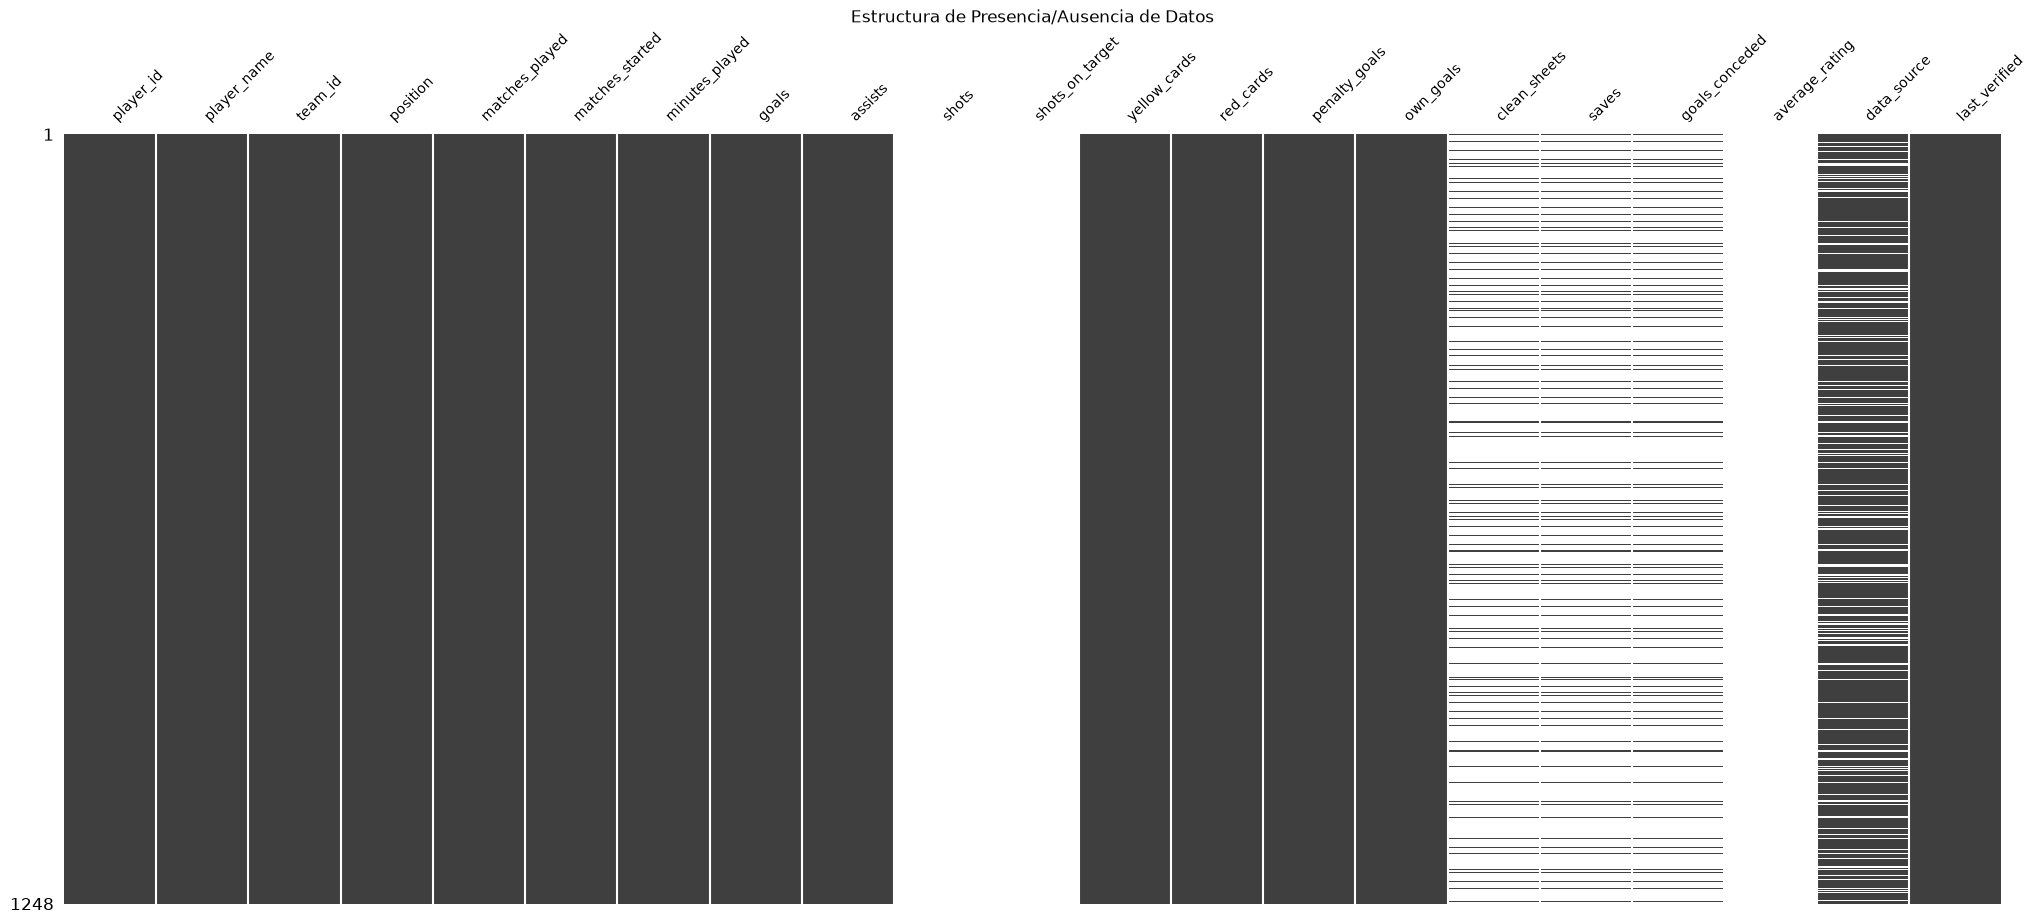

-- Auditoría MAR: % de nulos en 'saves' por Posición --


,position,saves
0,DEF,100.0
1,FWD,100.0
2,GK,0.0
3,MID,100.0


Cantidad de nulos tras limpieza: 0
Cantidad de filas duplicadas: 0


In [14]:
# Diagnóstico inicial de datos nulos
nulos = df_csv.isnull().sum()
porcentaje_nulos = (nulos / len(df_csv)) * 100
tabla_nulos = pd.DataFrame({'cantidad de nulos': nulos, 'Porcentaje': porcentaje_nulos})

print("--Tabla de nulos--")
print(tabla_nulos[tabla_nulos['cantidad de nulos']>0])

#DIAGNOSTICO VISUAL Y PRUEBA DE MECANISMO MAR
plt.figure(figsize=(10,4))
msno.matrix(df_csv, sparkline=False, fontsize=10)
plt.title("Estructura de Presencia/Ausencia de Datos")
plt.show()

def nulos_por_grupo(df, grupo_cols, target_col):
    return df.groupby(grupo_cols, observed=True)[target_col].apply(lambda x: x.isnull().mean() * 100).reset_index()

print("-- Auditoría MAR: % de nulos en 'saves' por Posición --")
display(nulos_por_grupo(df_csv, ['position'], 'saves'))


# Eliminación de columnas vacías e imputación de métricas de arqueros
columnas_vacias = ['shots', 'shots_on_target', 'average_rating']
df_csv.drop(columns=columnas_vacias, inplace=True, errors='ignore')

columna_arquero = ['clean_sheets', 'saves', 'goals_conceded']
df_csv[columna_arquero] = df_csv[columna_arquero].fillna(0)

if 'data_source' in df_csv.columns:
    df_csv['data_source'] = df_csv['data_source'].fillna('Sin especificar')

print('Cantidad de nulos tras limpieza:', df_csv.isnull().sum().sum())
print("Cantidad de filas duplicadas:", df_csv.duplicated().sum())

3. ANALISIS DE DATOS

In [16]:
# Corrección de tipos de datos para prevenir cálculos erróneos en correlaciones
df_csv['player_id'] = df_csv['player_id'].astype(str)
df_csv['team_id'] = df_csv['team_id'].astype(str)
df_csv['position'] = df_csv['position'].astype('category')

# Creación de métrica absoluta
df_csv['contribuciones_gol'] = df_csv['goals'] + df_csv['assists']

# Filtro estadístico: Muestra representativa (>= 90 minutos)
MIN_MINUTOS = 90
df_active = df_csv[df_csv['minutes_played'] >= MIN_MINUTOS].copy()

# Normalización de métricas P90
df_active['goals_per_90'] = (df_active['goals'] / df_active['minutes_played']) * 90
df_active['assists_per_90'] = (df_active['assists'] / df_active['minutes_played']) * 90
df_active['contrib_per_90'] = (df_active['contribuciones_gol'] / df_active['minutes_played']) * 90

cols_p90 = ['goals_per_90', 'assists_per_90', 'contrib_per_90']
df_active[cols_p90] = df_active[cols_p90].round(2)

print(f"Total plantilla: {len(df_csv)} | Jugadores activos (>=90 min): {len(df_active)}\n")

# Validación de caso atípico (Arqueros con gol/asistencia)
gk_con_goles = df_active[(df_active['position'] == 'GK') & (df_active['contribuciones_gol'] > 0)]
print(f"Cantidad de arqueros con aportes ofensivos: {len(gk_con_goles)}")
if not gk_con_goles.empty:
    print(gk_con_goles[['player_name', 'minutes_played', 'goals', 'assists', 'contrib_per_90']], "\n")

# Segmentación por rol táctico
df_field = df_active[df_active['position'] != 'GK'].copy()
df_gk = df_active[df_active['position'] == 'GK'].copy()

Total plantilla: 1248 | Jugadores activos (>=90 min): 767

Cantidad de arqueros con aportes ofensivos: 1
                  player_name  minutes_played  goals  assists  contrib_per_90
624  Thibaut Nicolas Courtois             570      0        1            0.16 



- Aca la idea es eliminar a los jugadores con menos de 90 minutos, para evitar promedios engañosos.
Alguien que entra que juega 5 minutos y hace un gol daria un valor irreal de 18 goles por partido.

- Se realiza una validación de los puestos , mas que nada para saber si hay algun arquero que tenga asistencias o goles
debido a que es muy poco comun.

- Se hace una division de posiciones entre jugadores de campo y arqueros , asi puedo sacar las estadisticas como atajadas.

4. ESTADISTICA

NOTAR:
 Media = 0.21 
 Mediana = 0 
 Mas del 50% de los jugadores no suman goles ni asistencia , el promedio sube a 0,21 porque un grupo reducido de delanteros tiene cifras muy altas.

 - Los arqueros tienen mas minutos jugados que los jugadores de campo
    301 min vs 258 min  

=== RESUMEN ESTADÍSTICO P90 (JUGADORES DE CAMPO) ===


,minutes_played,goals,assists,contrib_per_90
count,703.00,703.00,703.00,703.00
mean,258.43,0.40,0.27,0.21
std,120.22,0.98,0.69,0.38
min,90.00,0.00,0.00,0.00
25%,166.00,0.00,0.00,0.00
50%,252.00,0.00,0.00,0.00
75%,336.00,0.00,0.00,0.32
max,750.00,10.00,8.00,3.02


=== RESUMEN ESTADÍSTICO (ARQUEROS) ===


,minutes_played,saves,clean_sheets,goals_conceded
count,64.00,64.00,64.00,64.00
mean,301.44,10.81,0.86,4.91
std,140.99,5.96,1.11,2.38
min,90.00,0.00,0.00,0.00
25%,180.00,7.00,0.00,3.00
50%,270.00,9.00,0.00,5.00
75%,390.00,14.25,2.00,6.25
max,630.00,29.00,5.00,10.00


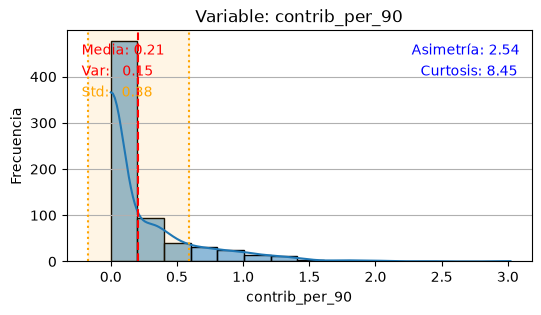

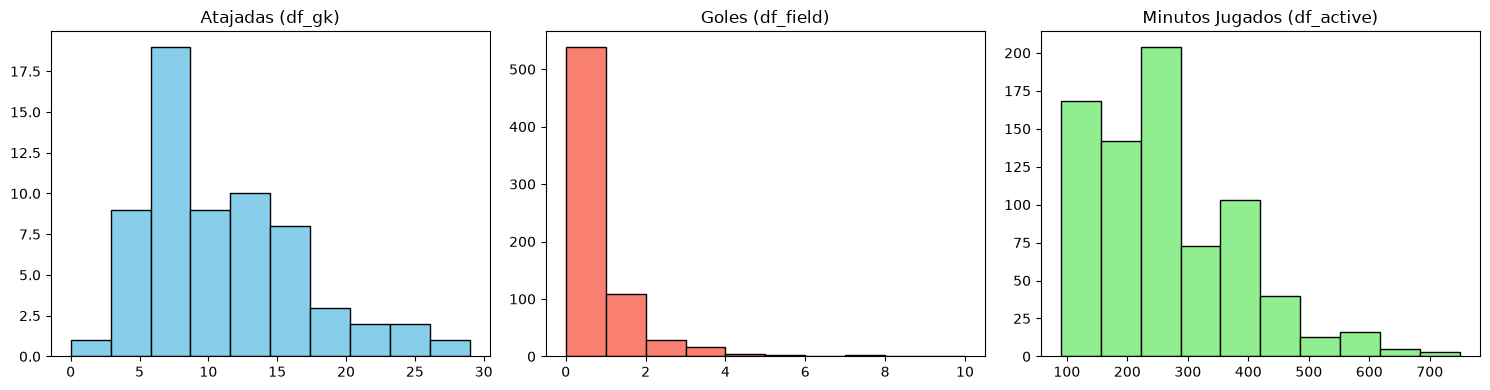

In [5]:
# Resumen numérico de métricas de campo (df_field)
print("=== RESUMEN ESTADÍSTICO P90 (JUGADORES DE CAMPO) ===")
display(df_field[['minutes_played', 'goals', 'assists', 'contrib_per_90']].describe().round(2))

# Resumen numérico de métricas de portería (df_gk)
print("=== RESUMEN ESTADÍSTICO (ARQUEROS) ===")
display(df_gk[['minutes_played', 'saves', 'clean_sheets', 'goals_conceded']].describe().round(2))

# Histograma principal de contribuciones P90
plot_histograma(df_field, 'contrib_per_90', mvd=True, snk=True, bins=15)

# Distribuciones univariadas individuales
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(df_gk['saves'], bins=10, color='skyblue', edgecolor='black')
ax[0].set_title("Atajadas (df_gk)")

ax[1].hist(df_field['goals'], bins=10, color='salmon', edgecolor='black')
ax[1].set_title('Goles (df_field)')

ax[2].hist(df_active['minutes_played'], bins=10, color='lightgreen', edgecolor='black')
ax[2].set_title('Minutos Jugados (df_active)')
plt.tight_layout()
plt.show()

Analisis de media y mediana 


5. Analisis univariado categorico

--- Distribución Categórica: Posiciones (Jugadores Activos >= 90 min) ---


,Cantidad de Jugadores,Porcentaje del Total (%)
position,,
DEF,284,37.03
MID,246,32.07
FWD,173,22.56
GK,64,8.34


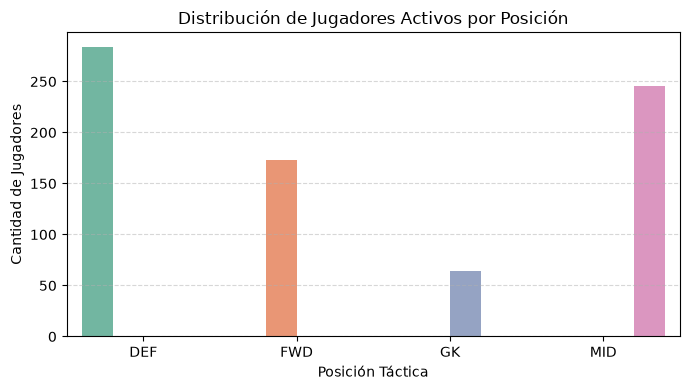

In [17]:
# Distribución por posición táctica sobre el plantel activo (incluye GK)
conteo = df_active['position'].value_counts()
porcentaje = df_active['position'].value_counts(normalize=True).mul(100).round(2)

tabla_posiciones = pd.DataFrame({
    'Cantidad de Jugadores': conteo,
    'Porcentaje del Total (%)': porcentaje
})

print("--- Distribución Categórica: Posiciones (Jugadores Activos >= 90 min) ---")
display(tabla_posiciones)

# Gráfico de conteo por categoría
plt.figure(figsize=(7, 4))
sns.countplot(data=df_active, x='position', palette='Set2', hue='position', legend=False)
plt.title('Distribución de Jugadores Activos por Posición')
plt.xlabel('Posición Táctica')
plt.ylabel('Cantidad de Jugadores')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

6. Relacion entre variables

/tmp/ipykernel_10308/2058102726.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_efectivos, x='contrib_per_90', y='player_name', palette='Blues_r')


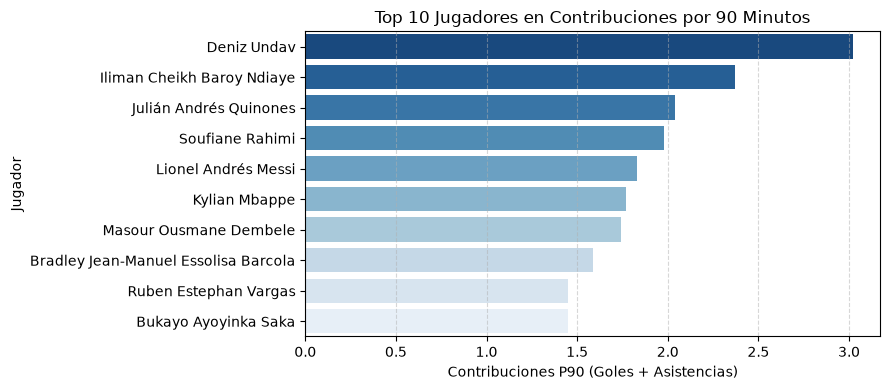

/tmp/ipykernel_10308/2058102726.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_field, x='position', y='contrib_per_90', palette='Set2', inner="box")


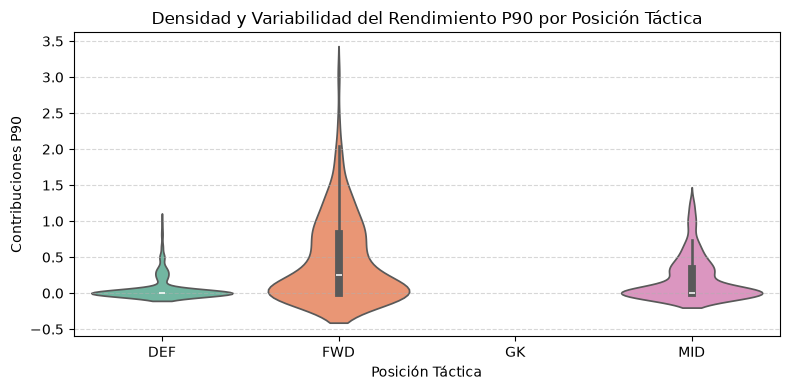

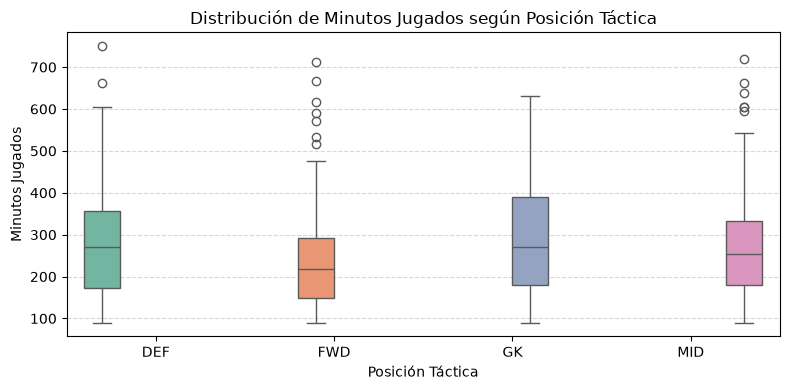

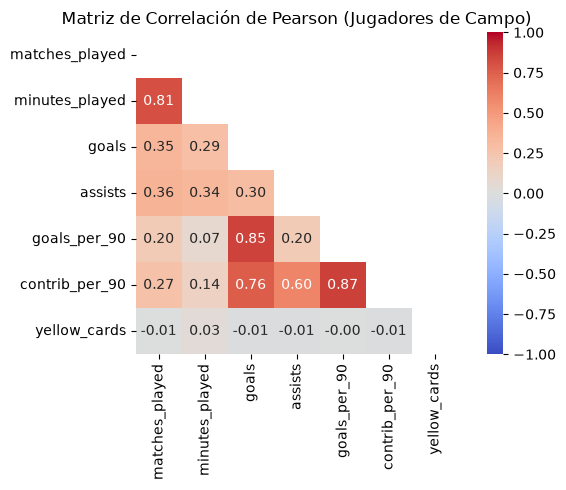

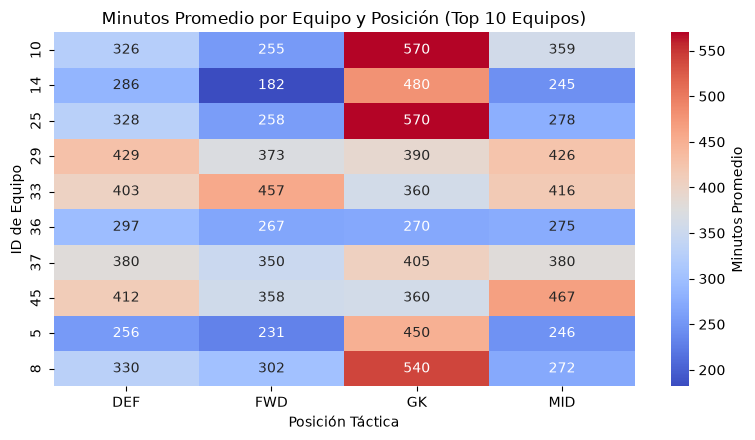

=== AUDITORÍA DE VALORES EXTREMOS ===
• Método IQR (Robust): Detecta 62 outliers (Umbral: > 0.80)
• Método 3-Sigma (Normal): Detecta 14 outliers (Umbral: > 1.35)


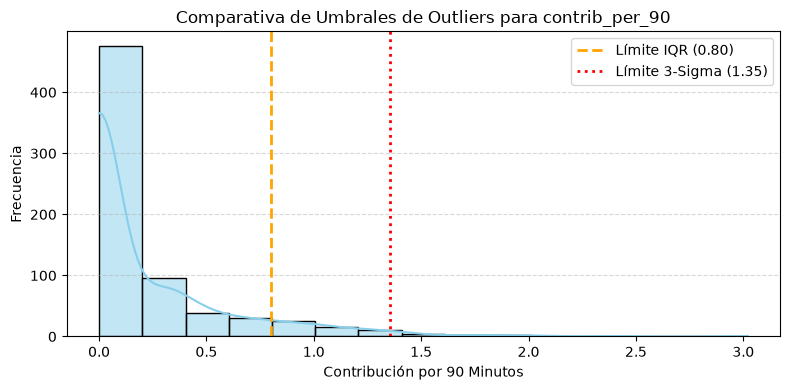

In [18]:
#Ranking de impacto individual (Top 10 P90)
top_efectivos = df_field.sort_values(by='contrib_per_90', ascending=False).head(10)

plt.figure(figsize=(9, 4))
sns.barplot(data=top_efectivos, x='contrib_per_90', y='player_name', palette='Blues_r')
plt.title('Top 10 Jugadores en Contribuciones por 90 Minutos')
plt.xlabel('Contribuciones P90 (Goles + Asistencias)')
plt.ylabel('Jugador')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Densidad y variabilidad de rendimiento por posición 
plt.figure(figsize=(8, 4))
sns.violinplot(data=df_field, x='position', y='contrib_per_90', palette='Set2', inner="box")
plt.title('Densidad y Variabilidad del Rendimiento P90 por Posición Táctica')
plt.xlabel('Posición Táctica')
plt.ylabel('Contribuciones P90')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Rodaje físico: Minutos jugados por Posición (Global)
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_active, x='position', y='minutes_played', palette='Set2', hue='position', legend=False)
plt.title('Distribución de Minutos Jugados según Posición Táctica')
plt.xlabel('Posición Táctica')
plt.ylabel('Minutos Jugados')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#Matriz de Correlación de Pearson P90
cols_num_campo = ['matches_played', 'minutes_played', 'goals', 'assists', 'goals_per_90', 'contrib_per_90', 'yellow_cards']
corr_matrix = df_field[cols_num_campo].corr()
mascara = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0, square=True, mask=mascara)
plt.title('Matriz de Correlación de Pearson (Jugadores de Campo)')
plt.tight_layout()
plt.show()

#Rotación táctica multivariada: Minutos por Equipo y Posición (Top 10 Equipos)
top_10_equipos = df_active['team_id'].value_counts().head(10).index
df_top_teams = df_active[df_active['team_id'].isin(top_10_equipos)]

tabla_pivote = df_top_teams.pivot_table(
    index='team_id', 
    columns='position', 
    values='minutes_played', 
    aggfunc='mean'
)

plt.figure(figsize=(8, 4.5))
sns.heatmap(tabla_pivote, cmap='coolwarm', annot=True, fmt=".0f", cbar_kws={'label': 'Minutos Promedio'})
plt.title('Minutos Promedio por Equipo y Posición (Top 10 Equipos)')
plt.xlabel('Posición Táctica')
plt.ylabel('ID de Equipo')
plt.tight_layout()
plt.show()

#Detección Comparativa de Outliers (IQR vs. 3-Sigma)
col_eval = 'contrib_per_90'
data_eval = df_field[col_eval].dropna()

q1, q3 = data_eval.quantile(0.25), data_eval.quantile(0.75)
iqr = q3 - q1
lim_sup_iqr = q3 + 1.5 * iqr

mu, sigma = data_eval.mean(), data_eval.std()
lim_sup_3s = mu + 3 * sigma

outliers_iqr = data_eval[data_eval > lim_sup_iqr]
outliers_3s = data_eval[data_eval > lim_sup_3s]

print("=== AUDITORÍA DE VALORES EXTREMOS ===")
print(f"• Método IQR (Robust): Detecta {len(outliers_iqr)} outliers (Umbral: > {lim_sup_iqr:.2f})")
print(f"• Método 3-Sigma (Normal): Detecta {len(outliers_3s)} outliers (Umbral: > {lim_sup_3s:.2f})")

plt.figure(figsize=(8, 4))
sns.histplot(data_eval, bins=15, kde=True, color='skyblue')
plt.axvline(lim_sup_iqr, color='orange', linestyle='--', linewidth=2, label=f'Límite IQR ({lim_sup_iqr:.2f})')
plt.axvline(lim_sup_3s, color='red', linestyle=':', linewidth=2, label=f'Límite 3-Sigma ({lim_sup_3s:.2f})')
plt.title(f'Comparativa de Umbrales de Outliers para {col_eval}')
plt.xlabel('Contribución por 90 Minutos')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

CONCLUSIONES DE LOS GRAFICOS

1. Minutos jugados por posicion
    Los que más minutos jugados tienen son los defensores y los arqueros, mientras que los que menos juegan son los delanteros.
    Los arqueros no tienen valores atipicos, es decir , se puede notar una clara distinción entre arqueros suplentes y titulares.
    Si bien los delanteros son los que menos juegan en tiempo , hay un grupo total indiscutido que se encuentra por fuera del rango.

2. Densidad y variabilidad
  - El punto blanco del centro es la mediana
  - La barra negra interna es el RIQ, donde se agrupa la mitad de los jugadores.
  - El ancho representa la frecuencia- densidad , donde es muy ancha, hay un monton de jugadores agrupados ,
    donde es fina  hay muy poquiitos.

    OBSERVACIONES:
    Delanteros: entre el 0.0 y 0.8 y la media es de 0.25 aprox 
    El grafico sigue hasta 3.4 , esto marca a ese jugador estrella que es un caso atipico con rendimiento muy bueno.

    Defensores: Casi sobre el 0 , significa que casi todos los defensores no suman ni goles ni asistencias.
                hay un hilo muy fino de casos atipicos.

    Medio: ESta asentada entre 0 y 0.4 la mayoría no registra goles.
            El RIQ es mayor que la defensa , sube hasta 0.75 , es mas variable que la defensa.

Hay una jerarquia marcada de forma descendente, de parte de los delanteros , medios y defensa. Los atacantes tienen una mediana 
que se despega a 0.

3. Matriz de correlación Pearson

    Los goles mandan (0.87): La contribucion total por partido (contrib_per_90) depende casi al 100 de los goles convertidos. Las asistencias pesan bastante menos (0.60).

    Mas partidos = mas minutos (0.81): Relación directa y lógica de rodaje acumulado.

    Golear no es asistir (0.30): Relación baja; los anotadores no son necesariamente los creadores de juego del equipo.

    Jugar más no te hace más efectivo (0.07): Sumar muchos minutos no garantiza tener un mejor promedio goleador por partido.

    Las tarjetas son independientes (~0.00): Las faltas/amarillas no tienen ninguna relación con meter goles, dar asistencias o jugar mucho tiempo.

El rendimiento ofensivo de un jugador está dominado por su capacidad goleadora directa (no por sus asistencias), y la indisciplina es un comportamiento totalmente aislado del aporte en ataque.

4. Metodo 3-Sigma - RIQ
  -Los datos te muestra que casi toda la liga esta cerca del 0, hay pocos o ningun gol. La franja que se afina 
  hacia la derecha son los atacantes que marcan diferencia.

  - Linea naranja (Limite RIQ 0,80) Toda la gente que queda a la derecha de esa linea (62 jugadores) representa a los futbolistas
  con un rendimiento ofensivo superior al resto.

  - Linea roja ( 3-Sigma 1,35): ES el corte exagerado. COmo el promedio se inflo, la linea se corrio tanto a la derecha que solo considera fuera 
    de serie a 14 superestrellas absolutas. 

  - El espacio entre las dos lineas son los 48 jugadores de gran nivel que el metodo ignora por haber usado un promedio engañoso.

  NOTA: 
  El metodo 3-Sigma fue inventado para datos simetricos. En futbol no funciona asi , los datos se amontonan todos a la izquierda
  y forman una cola larga hacia la derecha , usar 3-Sigma en futbol es usar una herramienta diseñada para un problema totalmente diferente.
  
  